In [2]:
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
import pandas as pd
from collections import defaultdict

In [4]:
# Đếm số lượng của 11 nhãn
categories = ['crab', 'fish', 'jellyfish', 'shrimp', 'small_fish', 'starfish', 'sea_cucumber', 'sea_urchin', 'scallop', 'diver', 'string']
labels_path = "../../dataset/detection/final/labels"
modes = ["test", "val", "train"]

# Khởi tạo dictionary để đếm
class_counts = defaultdict(int)
split_stats = {mode: defaultdict(int) for mode in modes}

for mode in modes:
    sub_folder_path = os.path.join(labels_path, mode)

    for label_file_name in os.listdir(sub_folder_path):
        if not label_file_name.endswith('.txt'):
            continue

        label_file_path = os.path.join(sub_folder_path, label_file_name)

        # Đọc file label theo từng dòng
        with open(label_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:  # Bỏ qua dòng trống
                    parts = line.split()
                    class_id = int(parts[0])  # Class index ở đầu dòng

                    # Đếm tổng và theo split
                    class_counts[class_id] += 1
                    split_stats[mode][class_id] += 1

print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)

data = []
for class_id, class_name in enumerate(categories):
    row = {
        'Class': class_id,
        'Name': class_name,
        'Total': class_counts[class_id],
        'Train': split_stats['train'][class_id],
        'Val': split_stats['val'][class_id],
        'Test': split_stats['test'][class_id]
    }
    data.append(row)

df = pd.DataFrame(data)
print(df.to_string(index=False))

print("\n" + "="*60)
print(f"Total objects count: {sum(class_counts.values())}")


CLASS DISTRIBUTION
 Class         Name  Total  Train  Val  Test
     0         crab   3188   2500  336   352
     1         fish    850    679   85    86
     2    jellyfish    163    130   15    18
     3       shrimp    143    105   21    17
     4   small_fish   2727   2184  288   255
     5     starfish   2039   1608  216   215
     6 sea_cucumber   3988   3801  187     0
     7   sea_urchin  10886  10330  556     0
     8      scallop   1152   1099   53     0
     9        diver   6042   4538  954   550
    10       string    243    192   51     0

Total objects count: 31421


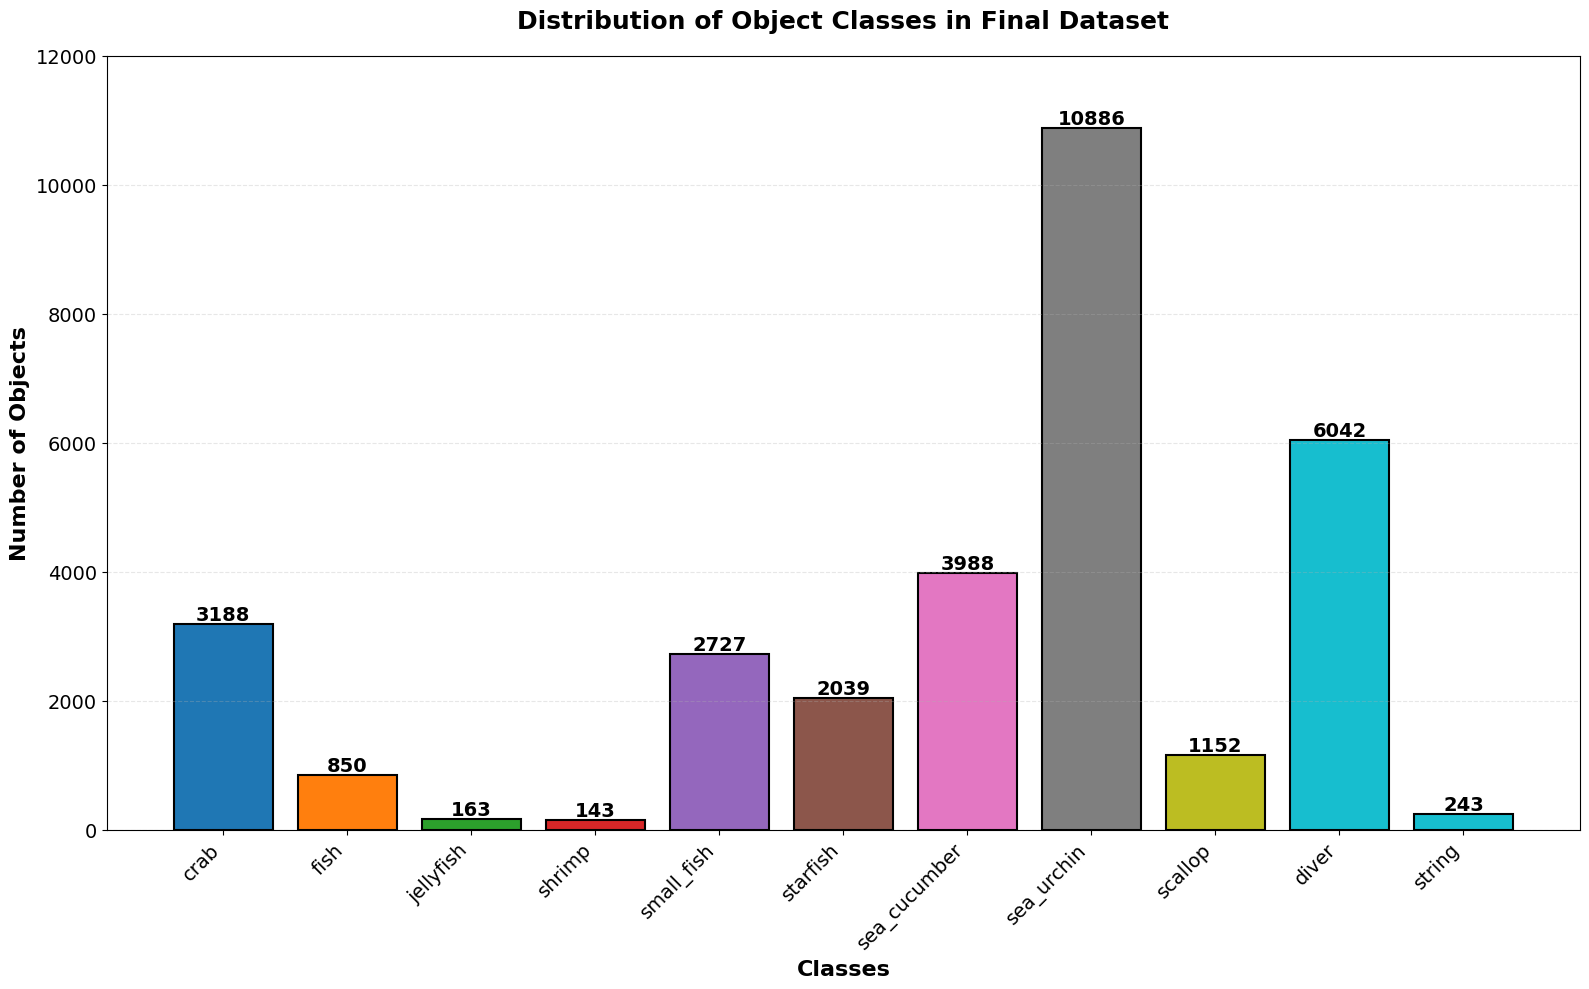

In [6]:
# Vẽ biểu đồ phân bố nhãn
plt.figure(figsize=(16, 10))

# Lấy dữ liệu từ DataFrame
class_names = df['Name'].tolist()
total_counts = df['Total'].tolist()

# Tạo màu sắc cho từng class
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

# Vẽ biểu đồ cột
bars = plt.bar(range(len(class_names)), total_counts, color=colors, edgecolor='black', linewidth=1.5)

# Thêm giá trị lên đầu mỗi cột
for i, (bar, count) in enumerate(zip(bars, total_counts)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}',
             ha='center', va='bottom', fontsize=14, fontweight='bold')

# Tùy chỉnh biểu đồ
plt.xlabel('Classes', fontsize=16, fontweight='bold')
plt.ylabel('Number of Objects', fontsize=16, fontweight='bold')
plt.title('Distribution of Object Classes in Final Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 12000)  # Giới hạn trục y lên 12000
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

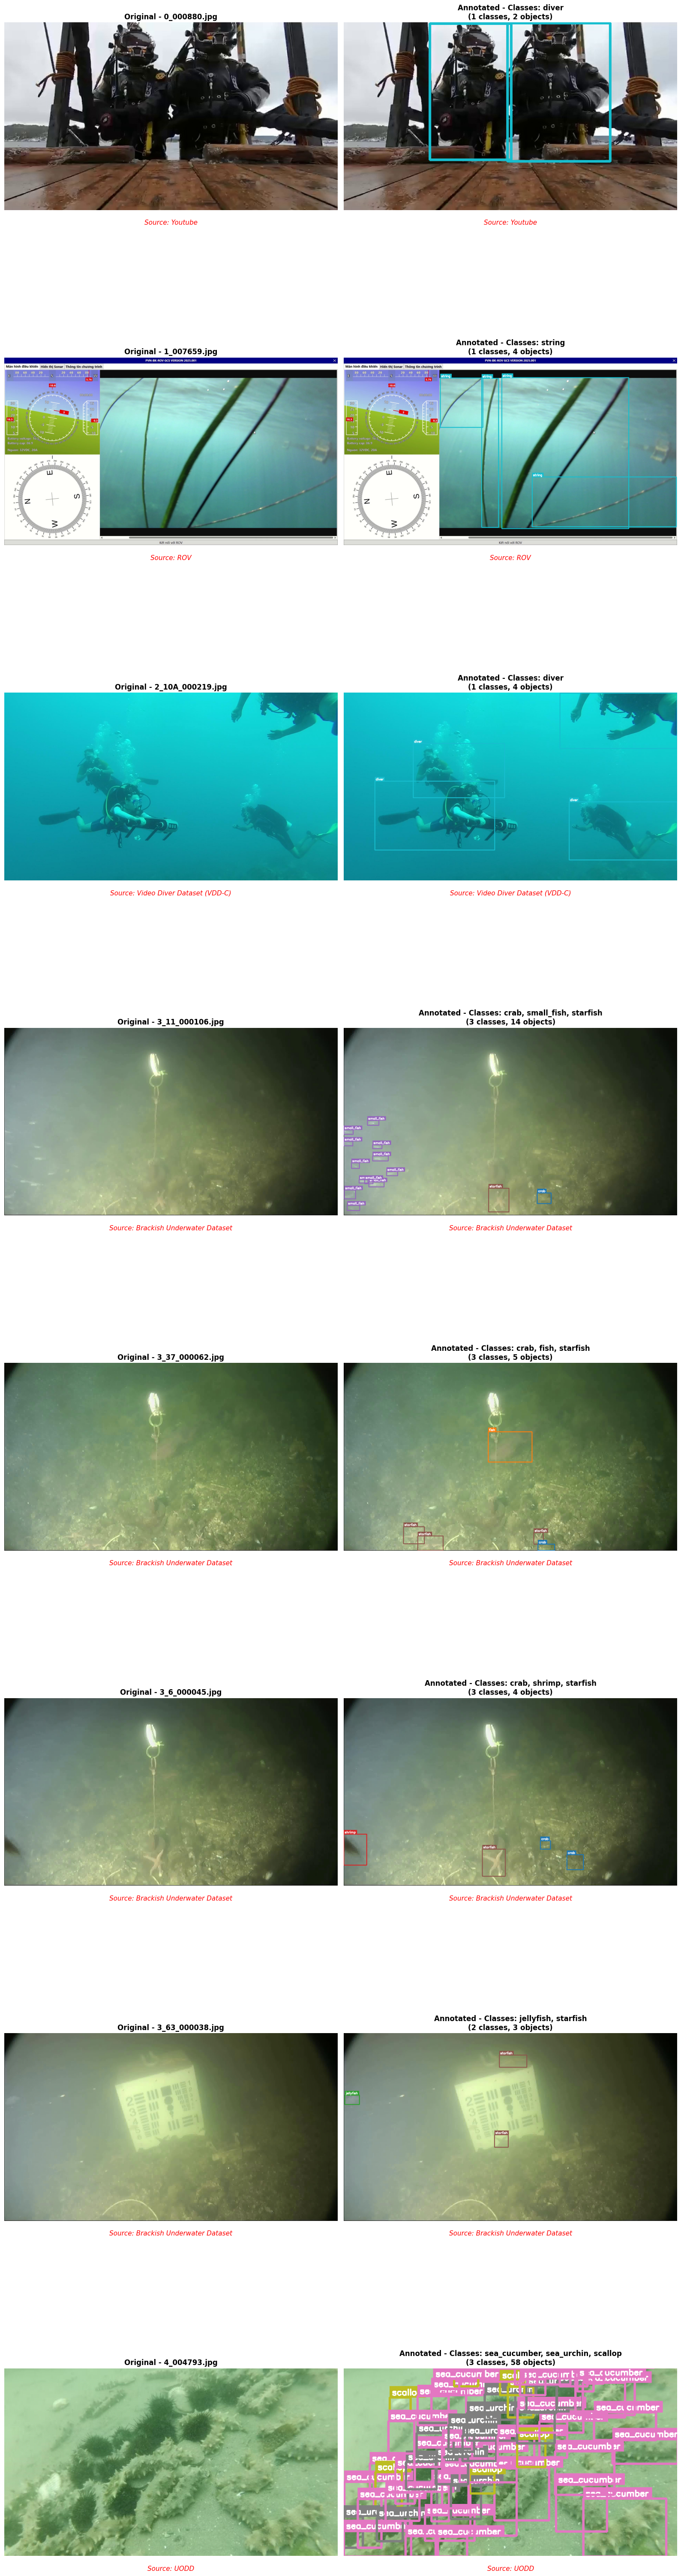

In [15]:
def find_representative_images_optimized(images_path: str, labels_path: str):

    prefixes_config = {
        '0_': {'num_images': 1, 'target_classes': None},
        '1_': {'num_images': 1, 'target_classes': None},
        '2_': {'num_images': 1, 'target_classes': None},
        '3_': {'num_images': None, 'target_classes': set(range(0, 6))},
        '4_': {'num_images': None, 'target_classes': {6, 7, 8}}
    }

    selected_images = []

    for prefix, config in prefixes_config.items():
        candidate_images = []

        for split in ['train', 'val', 'test']:
            img_dir = os.path.join(images_path, split)
            lbl_dir = os.path.join(labels_path, split)

            if not os.path.exists(img_dir) or not os.path.exists(lbl_dir):
                continue

            for img_name in os.listdir(img_dir):
                if img_name.startswith(prefix) and img_name.endswith(('.jpg', '.png')):
                    label_name = os.path.splitext(img_name)[0] + '.txt'
                    label_path = os.path.join(lbl_dir, label_name)

                    if os.path.exists(label_path):
                        with open(label_path, 'r') as f:
                            classes = set()
                            lines = f.readlines()
                            for line in lines:
                                if line.strip():
                                    class_id = int(line.split()[0])
                                    classes.add(class_id)

                        candidate_images.append({
                            'img_path': os.path.join(img_dir, img_name),
                            'label_path': label_path,
                            'num_classes': len(classes),
                            'num_objects': len(lines),
                            'classes': classes
                        })

        if prefix in ['0_', '1_', '2_']:
            candidate_images.sort(key=lambda x: (x['num_classes'], x['num_objects']), reverse=True)
            selected_images.extend(candidate_images[:1])

        elif prefix == '4_':
            target_classes = config['target_classes']
            perfect_matches = [img for img in candidate_images if target_classes.issubset(img['classes'])]

            if perfect_matches:
                perfect_matches.sort(key=lambda x: x['num_objects'], reverse=True)
                selected_images.append(perfect_matches[0])
            else:
                candidate_images.sort(key=lambda x: (x['num_classes'], x['num_objects']), reverse=True)
                if candidate_images:
                    selected_images.append(candidate_images[0])

        elif prefix == '3_':
            target_classes = config['target_classes']
            covered_classes = set()
            selected_for_prefix = []

            candidate_images.sort(key=lambda x: (x['num_classes'], x['num_objects']), reverse=True)

            for img in candidate_images:
                if covered_classes == target_classes:
                    break

                new_classes = img['classes'] - covered_classes
                if new_classes or len(selected_for_prefix) == 0:
                    selected_for_prefix.append(img)
                    covered_classes.update(img['classes'])

            selected_images.extend(selected_for_prefix)

    return selected_images


def draw_bboxes_on_image(img_path: str, label_path: str, categories: list):
    """
    Vẽ bounding boxes lên ảnh
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
    colors = (colors[:, :3] * 255).astype(np.uint8)

    with open(label_path, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split()
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:5])

                x1 = int((x_center - width/2) * w)
                y1 = int((y_center - height/2) * h)
                x2 = int((x_center + width/2) * w)
                y2 = int((y_center + height/2) * h)

                color = tuple(int(c) for c in colors[class_id])
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

                label_text = categories[class_id]
                (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                cv2.rectangle(img, (x1, y1 - text_h - 10), (x1 + text_w + 10, y1), color, -1)
                cv2.putText(img, label_text, (x1 + 5, y1 - 5),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return img


def get_source_label(prefix: str) -> str:
    """
    Trả về label nguồn dựa trên prefix
    """
    source_map = {
        '0_': 'Source: Youtube',
        '1_': 'Source: ROV',
        '2_': 'Source: Video Diver Dataset (VDD-C)',
        '3_': 'Source: Brackish Underwater Dataset',
        '4_': 'Source: UODD'
    }
    return source_map.get(prefix, 'Unknown Source')


def show_sample_images_optimized(images_path: str, labels_path: str, categories: list):
    """
    Hiển thị ảnh mẫu tối ưu với bounding boxes
    """
    selected_images = find_representative_images_optimized(images_path, labels_path)
    num_images = len(selected_images)

    fig, axes = plt.subplots(num_images, 2, figsize=(16, 8 * num_images))

    if num_images == 1:
        axes = np.array([axes])

    for idx, img_info in enumerate(selected_images):
        img_original = cv2.imread(img_info['img_path'])
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

        img_with_bbox = draw_bboxes_on_image(img_info['img_path'], img_info['label_path'], categories)

        # Lấy prefix từ tên file
        img_name = os.path.basename(img_info['img_path'])
        prefix = img_name.split('_')[0] + '_'
        source_label = get_source_label(prefix)

        # Hiển thị ảnh gốc
        axes[idx, 0].imshow(img_original)
        axes[idx, 0].axis('off')
        axes[idx, 0].set_title(f"Original - {img_name}",
                               fontsize=12, fontweight='bold')

        # Thêm text nguồn ở dưới ảnh gốc
        axes[idx, 0].text(0.5, -0.05, source_label,
                         transform=axes[idx, 0].transAxes,
                         ha='center', va='top',
                         fontsize=11, style='italic', color='red')

        # Hiển thị ảnh có bbox
        axes[idx, 1].imshow(img_with_bbox)
        axes[idx, 1].axis('off')

        class_names = [categories[c] for c in sorted(img_info['classes'])]
        title = f"Annotated - Classes: {', '.join(class_names)}\n({len(img_info['classes'])} classes, {img_info['num_objects']} objects)"
        axes[idx, 1].set_title(title, fontsize=12, fontweight='bold')

        # Thêm text nguồn ở dưới ảnh có bbox
        axes[idx, 1].text(0.5, -0.05, source_label,
                         transform=axes[idx, 1].transAxes,
                         ha='center', va='top',
                         fontsize=11, style='italic', color='red')

    plt.tight_layout()
    plt.show()


# Sử dụng
images_path = "../../dataset/detection/final/images"
labels_path = "../../dataset/detection/final/labels"
categories = ['crab', 'fish', 'jellyfish', 'shrimp', 'small_fish', 'starfish',
              'sea_cucumber', 'sea_urchin', 'scallop', 'diver', 'string']

show_sample_images_optimized(images_path, labels_path, categories)